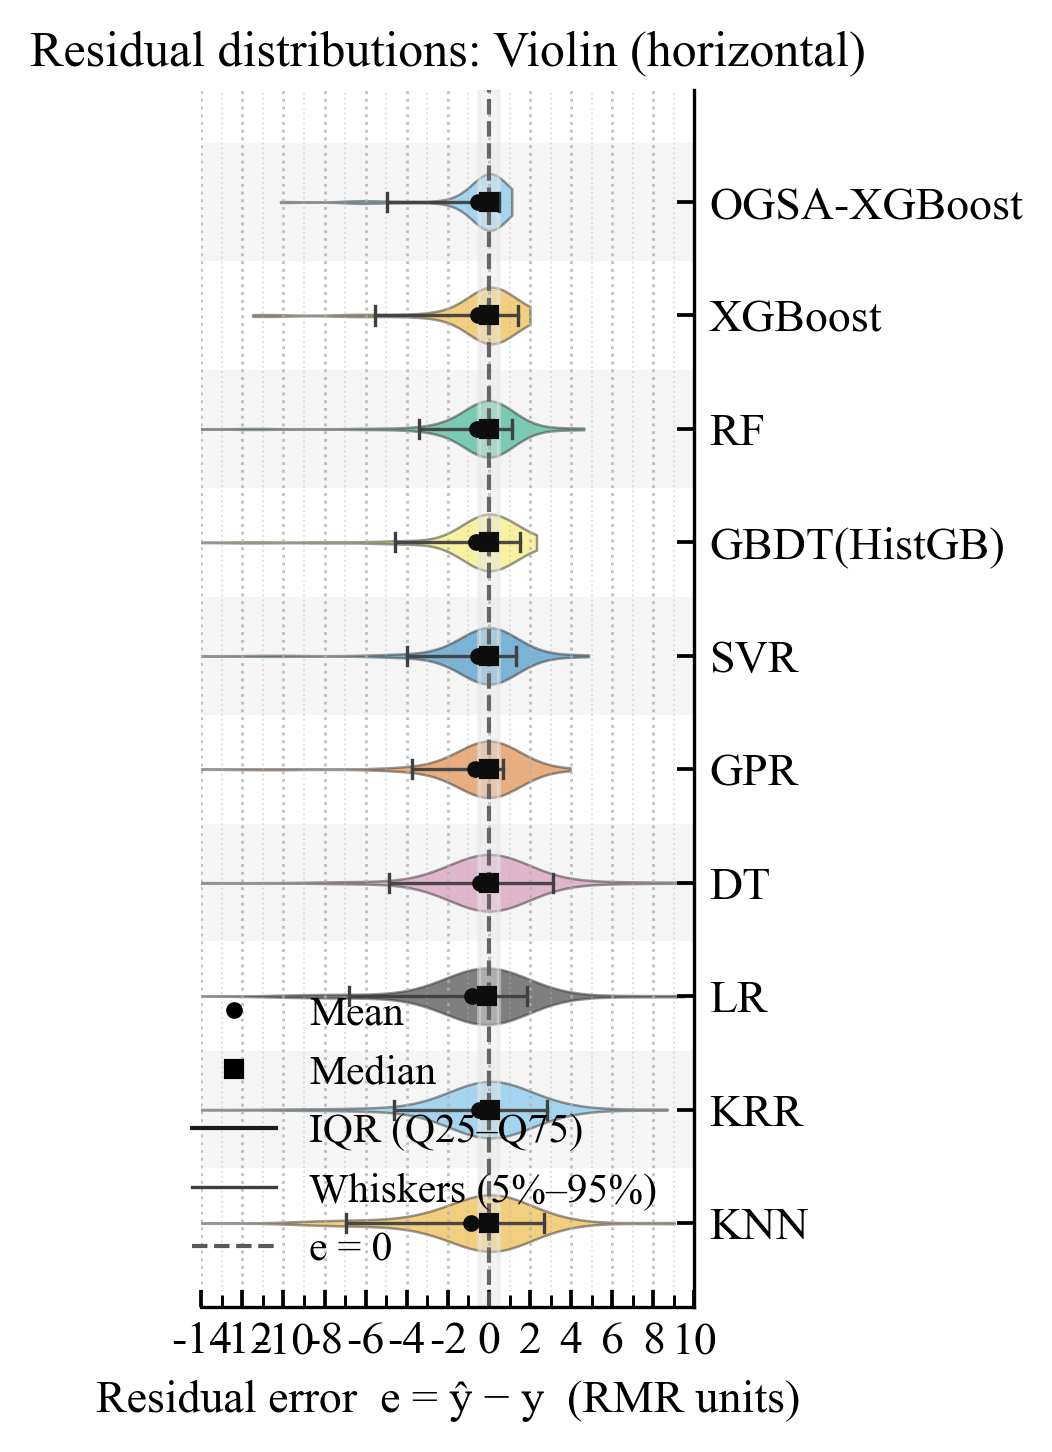

In [5]:
import os
import glob
import unicodedata
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "custom"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
mpl.rcParams["mathtext.it"] = "Times New Roman:italic"
mpl.rcParams["mathtext.bf"] = "Times New Roman:bold"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["axes.unicode_minus"] = False
BASE = 12
mpl.rcParams.update({
    "font.size": BASE,
    "axes.titlesize": BASE + 2,
    "axes.labelsize": BASE + 1,
    "xtick.labelsize": BASE,
    "ytick.labelsize": BASE,
    "legend.fontsize": BASE - 1,
})

ROOT_DIR = "RMR_Exports"

def _norm(s):
    if not isinstance(s, str):
        return ""
    return unicodedata.normalize("NFKC", s).strip().lower()

def pick_test_sheet(xl):
    for nm in xl.sheet_names:
        if _norm(nm) in ("sheet3", "sheet 3"):
            return nm
    for nm in xl.sheet_names:
        nmn = _norm(nm)
        if ("test" in nmn) or ("测试" in nmn):
            return nm
    return xl.sheet_names[-1]

def pick_true_pred_columns(df):
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No numeric columns for y_true/y_pred.")
    sc_t = {
        c: (10 if any(k in _norm(c) for k in ["true", "真实", "label", "target", "y_true", "rmr_true", "true_rmr"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    sc_p = {
        c: (10 if any(k in _norm(c) for k in ["pred", "预测", "estimate", "y_pred", "rmr_pred", "pred_rmr", "model"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    tcol = max(num_cols, key=lambda x: sc_t.get(x, 0))
    pcol = max(num_cols, key=lambda x: sc_p.get(x, 0))
    if tcol == pcol or (sc_t[tcol] < 5 and sc_p[pcol] < 5):
        combos = [
            ("True", "Pred"),
            ("真实", "预测"),
            ("RMR_true", "RMR_pred"),
            ("True_RMR", "Pred_RMR"),
            ("y_true", "y_pred"),
            ("Label", "Model"),
            ("RMR", "Pred_RMR"),
        ]
        low = {_norm(c): c for c in df.columns}
        for a, b in combos:
            if _norm(a) in low and _norm(b) in low:
                tcol, pcol = low[_norm(a)], low[_norm(b)]
                break
    if tcol == pcol:
        if len(num_cols) >= 2:
            tcol, pcol = num_cols[0], num_cols[1]
        else:
            raise ValueError("Cannot determine distinct true/pred columns.")
    return tcol, pcol

def parse_model(fp):
    return os.path.splitext(os.path.basename(fp))[0]

def key_simplify(name):
    return re.sub(r"[^a-z0-9]+", "", _norm(name))

xlsx_files = sorted(glob.glob(os.path.join(ROOT_DIR, "*.xlsx")))
if not xlsx_files:
    raise FileNotFoundError(f"未在 {ROOT_DIR} 找到 .xlsx 文件。")

residuals = {}
for fp in xlsx_files:
    model = parse_model(fp)
    try:
        xl = pd.ExcelFile(fp, engine="openpyxl")
    except Exception:
        xl = pd.ExcelFile(fp)
    sheet = pick_test_sheet(xl)
    df = xl.parse(sheet)

    tcol, pcol = pick_true_pred_columns(df)
    y_true = pd.to_numeric(df[tcol], errors="coerce").to_numpy()
    y_pred = pd.to_numeric(df[pcol], errors="coerce").to_numpy()
    m = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    if y_true.size == 0:
        continue

    e = y_pred - y_true
    residuals[model] = e

if not residuals:
    raise RuntimeError("未得到任何模型的有效测试集残差。")

ORDER_MANUAL = [
    "OGSA-XGBoost",
    "XGBoost",
    "RF",
    "GBDT",
    "SVR",
    "GPR",
    "DT",
    "LR",
    "KRR",
    "KNN",
]

present_keys = {key_simplify(k): k for k in residuals.keys()}
order = []
for name in ORDER_MANUAL:
    kn = key_simplify(name)
    if kn in present_keys:
        order.append(present_keys[kn])
    else:
        cand = [v for kk, v in present_keys.items() if kn in kk]
        if cand:
            order.append(cand[0])
order += [m for m in residuals.keys() if m not in order]

stats = {}
for m in order:
    e = np.asarray(residuals[m], dtype=float)
    e = e[~np.isnan(e)]
    if e.size == 0:
        continue
    q05, q25, q50, q75, q95 = np.percentile(e, [5, 25, 50, 75, 95])
    stats[m] = {
        "mean": float(np.mean(e)),
        "q05": q05,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "q95": q95,
        "MdAE": float(np.median(np.abs(e))),
        "RMSE": float(np.sqrt(np.mean(e * e))),
    }

XLIM_MODE = "manual"
MANUAL_XLIM = (-14.0, 10.0)
AUTO_SYMM_Q = (1.0, 99.0)
AUTO_SYMM_PAD = 0.06
AUTO_QTL = (0.5, 99.5)
AUTO_QTL_PAD = 0.04

all_e = np.concatenate([residuals[m] for m in order if m in residuals])
all_e = all_e[~np.isnan(all_e)]
if all_e.size == 0:
    raise RuntimeError("无有效残差用于设置横轴。")

if XLIM_MODE == "manual":
    x_lo, x_hi = MANUAL_XLIM
    if x_hi <= x_lo:
        x_lo, x_hi = x_hi, x_lo
elif XLIM_MODE == "auto_symmetric":
    p_low, p_high = np.percentile(all_e, [AUTO_SYMM_Q[0], AUTO_SYMM_Q[1]])
    lim = max(abs(p_low), abs(p_high))
    pad = AUTO_SYMM_PAD * (2 * lim)
    x_lo, x_hi = -lim - pad, lim + pad
else:
    p_low, p_high = np.percentile(all_e, [AUTO_QTL[0], AUTO_QTL[1]])
    span = max(1e-9, p_high - p_low)
    pad = AUTO_QTL_PAD * span
    x_lo, x_hi = p_low - pad, p_high + pad

DPI = 300
FIGSIZE = (3.2, 5.0)
TICK_FZ, LABEL_FZ, TITLE_FZ = 11, 11, 12
MEAN_MS, MEDIAN_MS = 3.0, 3.8
IQR_LW, WHISKER_LW, VIOLIN_EDGE_LW = 1.0, 0.8, 0.6
ZERO_BAND_HALF = 0.5

OI = ["#56B4E9", "#E69F00", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

for i in range(len(order)):
    if i % 2 == 0:
        ax.axhspan(i + 0.5, i + 1.5, color="0.96", zorder=0)

data = [np.asarray(residuals[m], dtype=float) for m in order]
parts = ax.violinplot(data, vert=False, showmeans=False, showmedians=False, showextrema=False)
for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(OI[i % len(OI)])
    body.set_alpha(0.5)
    body.set_linewidth(VIOLIN_EDGE_LW)
    body.set_edgecolor("0.2")

y_positions = np.arange(1, len(order) + 1)
for yi, m in zip(y_positions, order):
    if m not in stats:
        continue
    st = stats[m]
    ax.plot([st["q25"], st["q75"]], [yi, yi], lw=IQR_LW, color="0.10", alpha=0.95, solid_capstyle="butt", zorder=3)
    ax.plot([st["q05"], st["q25"]], [yi, yi], lw=WHISKER_LW, color="0.25", alpha=0.95, zorder=3)
    ax.plot([st["q75"], st["q95"]], [yi, yi], lw=WHISKER_LW, color="0.25", alpha=0.95, zorder=3)
    ax.plot([st["q05"], st["q05"]], [yi - 0.08, yi + 0.08], lw=WHISKER_LW, color="0.25", zorder=3)
    ax.plot([st["q95"], st["q95"]], [yi - 0.08, yi + 0.08], lw=WHISKER_LW, color="0.25", zorder=3)
    ax.plot(st["q50"], yi, marker="s", ms=MEDIAN_MS, color="0.05", linestyle="None", zorder=4)
    ax.plot(st["mean"], yi, marker="o", ms=MEAN_MS, color="0.05", linestyle="None", zorder=4)

if ZERO_BAND_HALF is not None and ZERO_BAND_HALF > 0:
    ax.axvspan(-ZERO_BAND_HALF, ZERO_BAND_HALF, color="0.90", alpha=0.45, zorder=1)
ax.axvline(0.0, color="0.35", lw=1.0, ls="--", alpha=0.90, zorder=2)

ax.set_xlim(x_lo, x_hi)
ax.set_yticks(y_positions)
ax.set_yticklabels(order)
ax.invert_yaxis()

ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(axis="y", left=False, right=True, labelleft=False, labelright=True)

ax.set_xlabel("Residual error  e = ŷ − y  (RMR units)", fontsize=LABEL_FZ)
ax.set_title("Residual distributions: Violin (horizontal)", fontsize=TITLE_FZ, pad=6)

ax.tick_params(which="both", direction="in", length=4, width=0.9, labelsize=TICK_FZ)
ax.tick_params(which="minor", length=3, width=0.7)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, axis="x", which="major", ls=":", lw=0.7, alpha=0.75)
ax.grid(True, axis="x", which="minor", ls=":", lw=0.45, alpha=0.40)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="None", label="Mean", markersize=MEAN_MS, color="black"),
    Line2D([0], [0], marker="s", linestyle="None", label="Median", markersize=MEDIAN_MS, color="black"),
    Line2D([0], [0], color="0.10", lw=IQR_LW, label="IQR (Q25–Q75)"),
    Line2D([0], [0], color="0.25", lw=WHISKER_LW, label="Whiskers (5%–95%)"),
    Line2D([0], [0], color="0.35", lw=1.0, ls="--", label="e = 0"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=BASE - 2, loc="lower right", ncol=1)

for spine in ["top", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd

TAUS = [1, 2, 5]

if "order" in globals():
    order = [("SVR" if m == "SVM" else m) for m in order]

if "residuals" in globals():
    residuals = {("SVR" if k == "SVM" else k): v for k, v in residuals.items()}

rows = []
for m in order:
    if m not in residuals:
        continue
    e = np.asarray(residuals[m], dtype=float)
    e = e[~np.isnan(e)]
    if e.size == 0:
        continue

    ae = np.abs(e)
    n = int(e.size)
    mean = float(np.mean(e))
    std = float(np.std(e, ddof=1)) if n > 1 else 0.0

    if n > 2 and std > 0:
        m3 = float(np.mean((e - mean) ** 3))
        m4 = float(np.mean((e - mean) ** 4))
        skew = m3 / (std ** 3)
        ekurt = m4 / (std ** 4) - 3.0
    else:
        skew, ekurt = np.nan, np.nan

    mae = float(np.mean(ae))
    mdae = float(np.median(ae))
    rmse = float(np.sqrt(np.mean(e * e)))
    q05 = float(np.percentile(e, 5))
    q25 = float(np.percentile(e, 25))
    q50 = float(np.percentile(e, 50))
    q75 = float(np.percentile(e, 75))
    q95 = float(np.percentile(e, 95))
    q90ae = float(np.quantile(ae, 0.90))
    q95ae = float(np.quantile(ae, 0.95))

    row = {
        "Model": m,
        "N_test": n,
        "ME": mean,
        "Std": std,
        "Skew": skew,
        "ExcessKurtosis": ekurt,
        "MAE": mae,
        "MdAE": mdae,
        "RMSE": rmse,
        "Q05(e)": q05,
        "Q25(e)": q25,
        "Median(e)": q50,
        "Q75(e)": q75,
        "Q95(e)": q95,
        "Q90(|e|)": q90ae,
        "Q95(|e|)": q95ae,
    }

    for t in TAUS:
        row[f"Pr(|e|<= {t})"] = float(np.mean(ae <= t))

    rows.append(row)

stats_df = pd.DataFrame(rows)
stats_df = stats_df.set_index("Model").loc[order].reset_index()

print(stats_df.to_string(index=False))
display(stats_df)

       Model  N_test        ME      Std      Skew  ExcessKurtosis      MAE     MdAE     RMSE    Q05(e)    Q25(e)  Median(e)   Q75(e)   Q95(e)  Q90(|e|)  Q95(|e|)  Pr(|e|<= 1)  Pr(|e|<= 2)  Pr(|e|<= 5)
OGSA-XGBoost      68 -0.511342 1.846719 -3.379276       11.900282 0.775169 0.205629 1.903074 -4.971580 -0.228231   0.005817 0.198063 0.468017  1.432490  4.971580     0.852941     0.926471     0.941176
     XGBoost      68 -0.548592 2.365194 -2.971768        9.544585 1.128742 0.357003 2.410981 -5.527075 -0.285418   0.002688 0.349962 1.393262  2.191871  5.527075     0.735294     0.897059     0.941176
          RF      68 -0.560237 2.639070 -3.667787       16.863907 1.019708 0.155925 2.678831 -3.405692 -0.132738  -0.000550 0.155263 1.121904  2.487225  4.356586     0.794118     0.852941     0.955882
GBDT(HistGB)      68 -0.623055 2.769343 -3.666704       15.027543 1.162424 0.353357 2.818630 -4.584291 -0.379676  -0.021909 0.224731 1.534112  2.005707  4.584291     0.779412     0.897059     0.95

,Model,N_test,ME,Std,Skew,ExcessKurtosis,MAE,MdAE,RMSE,Q05(e),Q25(e),Median(e),Q75(e),Q95(e),Q90(|e|),Q95(|e|),Pr(|e|<= 1),Pr(|e|<= 2),Pr(|e|<= 5)
0,OGSA-XGBoost,68,-0.511342,1.846719,-3.379276,11.900282,0.775169,0.205629,1.903074,-4.971580,-0.228231,0.005817,0.198063,0.468017,1.432490,4.971580,0.852941,0.926471,0.941176
1,XGBoost,68,-0.548592,2.365194,-2.971768,9.544585,1.128742,0.357003,2.410981,-5.527075,-0.285418,0.002688,0.349962,1.393262,2.191871,5.527075,0.735294,0.897059,0.941176
2,RF,68,-0.560237,2.639070,-3.667787,16.863907,1.019708,0.155925,2.678831,-3.405692,-0.132738,-0.000550,0.155263,1.121904,2.487225,4.356586,0.794118,0.852941,0.955882
3,GBDT(HistGB),68,-0.623055,2.769343,-3.666704,15.027543,1.162424,0.353357,2.818630,-4.584291,-0.379676,-0.021909,0.224731,1.534112,2.005707,4.584291,0.779412,0.897059,0.955882
4,SVR,68,-0.548510,2.967941,-4.276344,23.261294,1.145625,0.266258,2.996665,-3.987846,-0.414925,-0.001204,0.192604,1.301918,2.706703,4.686548,0.779412,0.867647,0.955882
5,GPR,68,-0.685373,3.336321,-5.371209,33.069106,1.074859,0.165533,3.381875,-3.737909,-0.178242,-0.000328,0.164531,0.683755,2.129109,4.019386,0.823529,0.897059,0.970588
6,DT,68,-0.459297,4.287370,-3.007225,15.726948,1.609110,0.179167,4.280441,-4.855500,-0.059583,0.000000,0.250000,3.112750,4.148000,7.502333,0.720588,0.852941,0.911765
7,LR,68,-0.836315,4.366219,-4.288596,26.488840,1.709336,0.324767,4.413949,-6.816633,-0.674250,-0.099658,0.177507,1.831222,4.779874,8.145096,0.691176,0.838235,0.897059
8,KRR,68,-0.489986,4.219475,-4.917924,31.889135,1.593430,0.425185,4.216898,-4.627754,-0.297575,0.033705,0.524541,2.841188,3.062673,5.838159,0.676471,0.808824,0.926471
9,KNN,68,-0.864147,4.041890,-3.574664,20.094220,1.922500,0.741000,4.104068,-6.966100,-1.094000,0.000000,0.505000,2.664500,5.171800,7.857900,0.632353,0.720588,0.897059


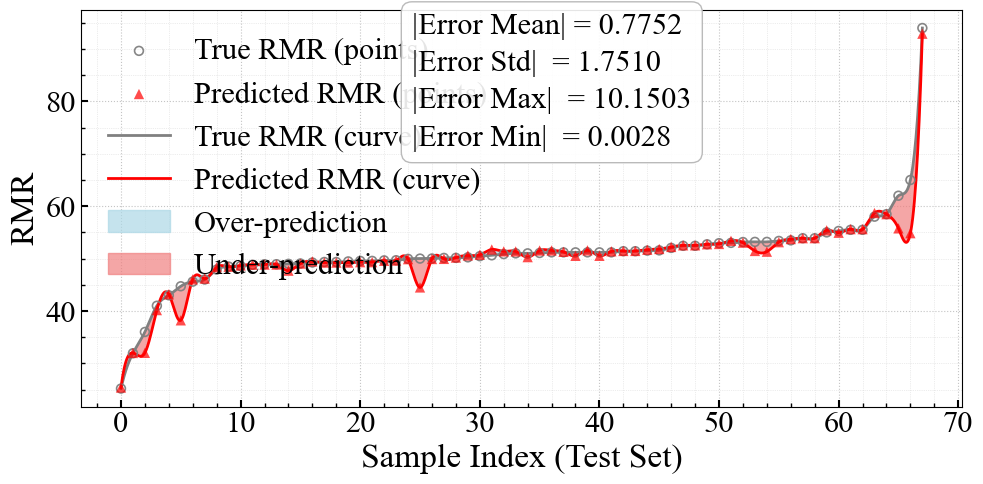

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

train_results = pd.read_excel("OGSA-XGBoost_Test.xlsx")

y_train = train_results["Test Values"].values
y_train_pred = train_results["Predicted Values"].values
sample_index = train_results["Sample Index"].values

errors = np.abs(y_train_pred - y_train)

interp_func_true = interpolate.interp1d(sample_index, y_train, kind="cubic", fill_value="extrapolate")
interp_func_pred = interpolate.interp1d(sample_index, y_train_pred, kind="cubic", fill_value="extrapolate")

sample_index_smooth = np.linspace(sample_index.min(), sample_index.max(), 1000)

y_train_smooth = interp_func_true(sample_index_smooth)
y_train_pred_smooth = interp_func_pred(sample_index_smooth)

above = y_train_pred_smooth >= y_train_smooth
below = ~above

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    sample_index, y_train, s=40,
    facecolors="none", edgecolors="gray", linewidths=1.2,
    marker="o", alpha=0.95, zorder=5, label="True RMR (points)"
)

ax.scatter(
    sample_index, y_train_pred, s=55,
    color="red", edgecolors="none",
    marker="^", alpha=0.70, zorder=5, label="Predicted RMR (points)"
)

ax.plot(sample_index_smooth, y_train_smooth, label="True RMR (curve)", color="gray", lw=2, zorder=4)
ax.plot(sample_index_smooth, y_train_pred_smooth, label="Predicted RMR (curve)", color="red", lw=2, zorder=4)

ax.fill_between(
    sample_index_smooth, y_train_smooth, y_train_pred_smooth,
    where=above, color="lightblue", alpha=0.7, label="Over-prediction", zorder=2
)
ax.fill_between(
    sample_index_smooth, y_train_smooth, y_train_pred_smooth,
    where=below, color="lightcoral", alpha=0.7, label="Under-prediction", zorder=2
)

ax.grid(True, which="major", axis="both", linestyle=":", linewidth=0.8, alpha=0.75)
ax.grid(True, which="minor", axis="both", linestyle=":", linewidth=0.5, alpha=0.45)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.set_xlabel("Sample Index (Test Set)", fontsize=24)
ax.set_ylabel("RMR", fontsize=24)

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="upper left", fontsize=22, frameon=False, ncol=1)

error_mean = np.mean(errors)
error_std = np.std(errors, ddof=1) if errors.size > 1 else 0.0
error_max = np.max(errors)
error_min = np.min(errors)
stats_text = (
    f"|Error Mean| = {error_mean:.4f}\n"
    f"|Error Std|  = {error_std:.4f}\n"
    f"|Error Max|  = {error_max:.4f}\n"
    f"|Error Min|  = {error_min:.4f}"
)

plt.figtext(
    0.42, 0.68, stats_text, fontsize=22, color="black",
    ha="left", va="bottom", linespacing=1.5,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9, boxstyle="round,pad=0.35")
)

ax.tick_params(axis="both", which="major", labelsize=22, direction="in", length=5, width=1.5)
ax.tick_params(axis="both", which="minor", labelsize=20, direction="in", length=3, width=1)

plt.tight_layout()
plt.show()

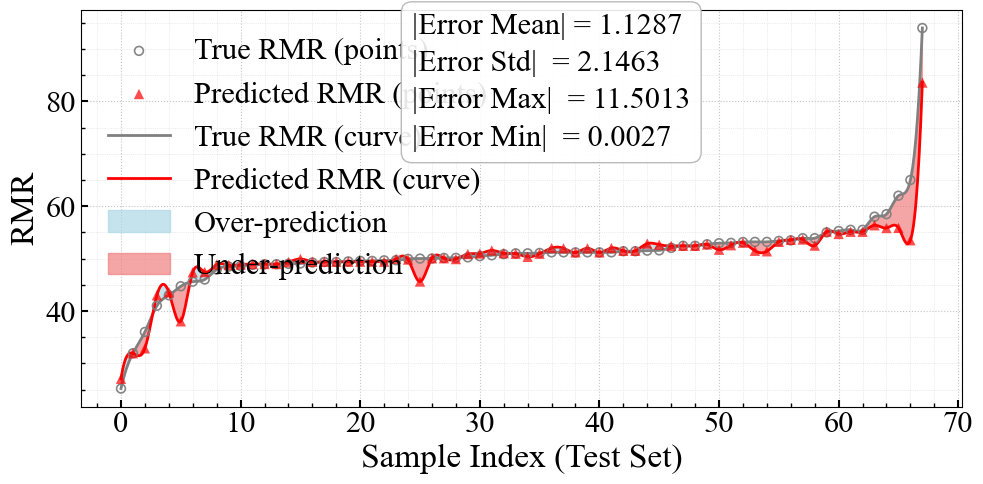

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

train_results = pd.read_excel("XGBoost_Test.xlsx")

y_train = train_results["Test Values"].values
y_train_pred = train_results["Predicted Values"].values
sample_index = train_results["Sample Index"].values

errors = np.abs(y_train_pred - y_train)

interp_func_true = interpolate.interp1d(sample_index, y_train, kind="cubic", fill_value="extrapolate")
interp_func_pred = interpolate.interp1d(sample_index, y_train_pred, kind="cubic", fill_value="extrapolate")

sample_index_smooth = np.linspace(sample_index.min(), sample_index.max(), 1000)

y_train_smooth = interp_func_true(sample_index_smooth)
y_train_pred_smooth = interp_func_pred(sample_index_smooth)

above = y_train_pred_smooth >= y_train_smooth
below = ~above

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    sample_index, y_train, s=40,
    facecolors="none", edgecolors="gray", linewidths=1.2,
    marker="o", alpha=0.95, zorder=5, label="True RMR (points)"
)

ax.scatter(
    sample_index, y_train_pred, s=55,
    color="red", edgecolors="none",
    marker="^", alpha=0.70, zorder=5, label="Predicted RMR (points)"
)

ax.plot(sample_index_smooth, y_train_smooth, label="True RMR (curve)", color="gray", lw=2, zorder=4)
ax.plot(sample_index_smooth, y_train_pred_smooth, label="Predicted RMR (curve)", color="red", lw=2, zorder=4)

ax.fill_between(
    sample_index_smooth, y_train_smooth, y_train_pred_smooth,
    where=above, color="lightblue", alpha=0.7, label="Over-prediction", zorder=2
)
ax.fill_between(
    sample_index_smooth, y_train_smooth, y_train_pred_smooth,
    where=below, color="lightcoral", alpha=0.7, label="Under-prediction", zorder=2
)

ax.grid(True, which="major", axis="both", linestyle=":", linewidth=0.8, alpha=0.75)
ax.grid(True, which="minor", axis="both", linestyle=":", linewidth=0.5, alpha=0.45)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.set_xlabel("Sample Index (Test Set)", fontsize=24)
ax.set_ylabel("RMR", fontsize=24)

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="upper left", fontsize=22, frameon=False, ncol=1)

error_mean = np.mean(errors)
error_std = np.std(errors, ddof=1) if errors.size > 1 else 0.0
error_max = np.max(errors)
error_min = np.min(errors)
stats_text = (
    f"|Error Mean| = {error_mean:.4f}\n"
    f"|Error Std|  = {error_std:.4f}\n"
    f"|Error Max|  = {error_max:.4f}\n"
    f"|Error Min|  = {error_min:.4f}"
)

plt.figtext(
    0.42, 0.68, stats_text, fontsize=22, color="black",
    ha="left", va="bottom", linespacing=1.5,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9, boxstyle="round,pad=0.35")
)

ax.tick_params(axis="both", which="major", labelsize=22, direction="in", length=5, width=1.5)
ax.tick_params(axis="both", which="minor", labelsize=20, direction="in", length=3, width=1)

plt.tight_layout()
plt.show()